# 🧠 Deep Learning Asoslari - Lecture

## Modulga Xush Kelibsiz!

Bu lecture'da biz neural networks'ning barcha asoslarini o'rganamiz:

1. **Perceptron** - Eng oddiy neyron
2. **Activation Functions** - Non-linearity
3. **Forward Propagation** - Ma'lumotlarni oldinga o'tkazish
4. **Backpropagation** - Xatolarni orqaga tarqatish
5. **Neural Network** from scratch
6. **Keras** - High-level implementation
7. **PyTorch** - Research framework

In [2]:
# Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_circles, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Deep Learning frameworks
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# PyTorch (optional)
# import torch
# import torch.nn as nn
# import torch.optim as optim

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)
tf.random.set_seed(42)

print("✅ Libraries imported successfully!")
print(f"📦 TensorFlow version: {tf.__version__}")
print(f"🔢 NumPy version: {np.__version__}")

✅ Libraries imported successfully!
📦 TensorFlow version: 2.16.2
🔢 NumPy version: 1.26.4


---

## 1️⃣ Perceptron - Eng Oddiy Neyron

Perceptron - 1957 yilda Frank Rosenblatt tomonidan yaratilgan birinchi sun'iy neyron.

### Formula:

$$y = \begin{cases} 1 & \text{if } w \cdot x + b > 0 \\ 0 & \text{otherwise} \end{cases}$$

Bu yerda:
- $x$ = input features
- $w$ = weights (og'irliklar)
- $b$ = bias
- $y$ = prediction

In [4]:
class Perceptron:
    """Single Perceptron Implementation"""
    
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.errors = []  # Track errors per iteration
    
    def activation(self, z):
        """Step function: 1 if z > 0, else 0"""
        return np.where(z > 0, 1, 0)
    
    def fit(self, X, y):
        """Train the perceptron"""
        n_samples, n_features = X.shape
        
        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # Training loop
        for iteration in range(self.n_iterations):
            errors = 0
            
            for idx, x_i in enumerate(X):
                # Forward pass
                z = np.dot(x_i, self.weights) + self.bias
                y_pred = self.activation(z)
                
                # Update weights if prediction is wrong
                if y[idx] != y_pred:
                    update = self.learning_rate * (y[idx] - y_pred)
                    self.weights += update * x_i
                    self.bias += update
                    errors += 1
            
            self.errors.append(errors)
            
            # Early stopping if no errors
            if errors == 0:
                print(f"✅ Converged at iteration {iteration + 1}")
                break
    
    def predict(self, X):
        """Make predictions"""
        z = np.dot(X, self.weights) + self.bias
        return self.activation(z)

print("✅ Perceptron class defined!")

✅ Perceptron class defined!


In [5]:
# Test Perceptron on simple linearly separable data
# Create simple AND gate dataset
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

print("🔢 AND Gate Dataset:")
print("\nInput (X):")
print(X_and)
print("\nOutput (y):")
print(y_and)

# Train perceptron
perceptron = Perceptron(learning_rate=0.1, n_iterations=100)
perceptron.fit(X_and, y_and)

# Make predictions
y_pred = perceptron.predict(X_and)

print("\n📊 Results:")
print(f"Predictions: {y_pred}")
print(f"True labels: {y_and}")
print(f"Accuracy: {accuracy_score(y_and, y_pred):.2%}")
print(f"\nLearned weights: {perceptron.weights}")
print(f"Learned bias: {perceptron.bias:.4f}")

🔢 AND Gate Dataset:

Input (X):
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Output (y):
[0 0 0 1]
✅ Converged at iteration 6

📊 Results:
Predictions: [0 0 0 1]
True labels: [0 0 0 1]
Accuracy: 100.00%

Learned weights: [0.2 0.1]
Learned bias: -0.2000


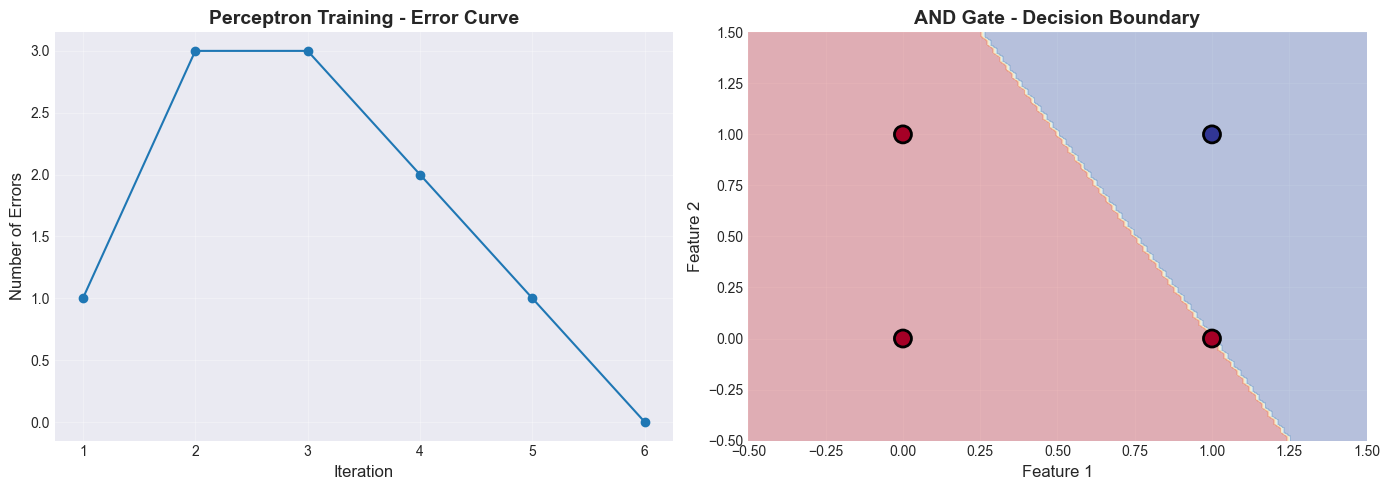

✅ Perceptron successfully learned AND gate!


In [6]:
# Visualize training progress
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Error curve
axes[0].plot(range(1, len(perceptron.errors) + 1), perceptron.errors, marker='o')
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Number of Errors', fontsize=12)
axes[0].set_title('Perceptron Training - Error Curve', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Decision boundary
x_min, x_max = X_and[:, 0].min() - 0.5, X_and[:, 0].max() + 0.5
y_min, y_max = X_and[:, 1].min() - 0.5, X_and[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
Z = perceptron.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

axes[1].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
axes[1].scatter(X_and[:, 0], X_and[:, 1], c=y_and, cmap='RdYlBu', 
                edgecolors='black', s=150, linewidths=2)
axes[1].set_xlabel('Feature 1', fontsize=12)
axes[1].set_ylabel('Feature 2', fontsize=12)
axes[1].set_title('AND Gate - Decision Boundary', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Perceptron successfully learned AND gate!")

### 🎯 Perceptron Limitations

**Problem:** Perceptron faqat **linearly separable** data'ni to'g'ri klassifikatsiya qila oladi.

**XOR Problem** - Klassik misol:

In [7]:
"""
AND - va amali ko'paytirish bo'ladi
OR - yoki amali qo'shish bo'ladi 
NOT - inkor amali
XOR - o'xshashlikni inkor qilish amali
0 0 -> 0 
1 1 -> 0
0 1 -> 1
1 0 -> 1

"""
# XOR gate - NOT linearly separable!
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])  # XOR output

print("🔢 XOR Gate Dataset:")
print("\nInput (X):")
print(X_xor)
print("\nOutput (y):")
print(y_xor)

# Try to train perceptron on XOR
perceptron_xor = Perceptron(learning_rate=0.1, n_iterations=100)
perceptron_xor.fit(X_xor, y_xor)

y_pred_xor = perceptron_xor.predict(X_xor)

print("\n📊 XOR Results:")
print(f"Predictions: {y_pred_xor}")
print(f"True labels: {y_xor}")
print(f"Accuracy: {accuracy_score(y_xor, y_pred_xor):.2%}")
print("\n❌ Perceptron FAILED on XOR! We need MULTI-LAYER networks.")

🔢 XOR Gate Dataset:

Input (X):
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Output (y):
[0 1 1 0]

📊 XOR Results:
Predictions: [1 1 0 0]
True labels: [0 1 1 0]
Accuracy: 50.00%

❌ Perceptron FAILED on XOR! We need MULTI-LAYER networks.


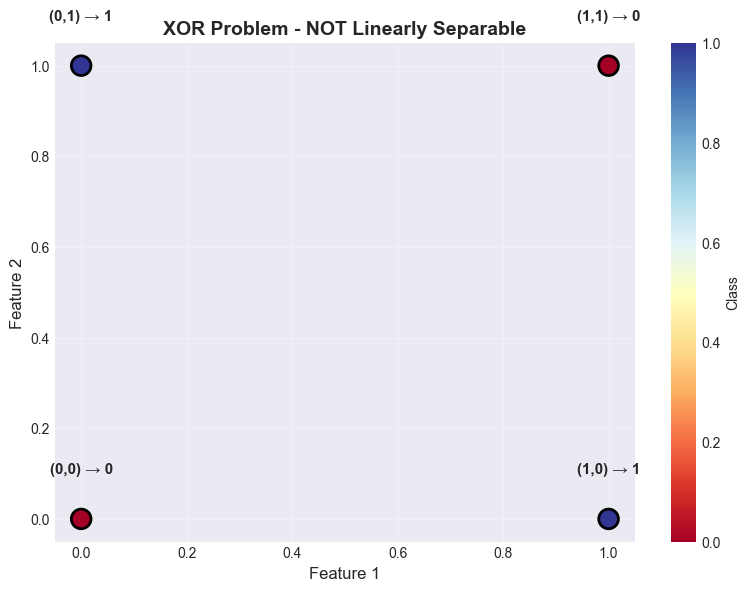

💡 Solution: We need HIDDEN LAYERS to solve XOR!


In [8]:
# Visualize XOR problem
plt.figure(figsize=(8, 6))
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, cmap='RdYlBu', 
            s=200, edgecolors='black', linewidths=2)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('XOR Problem - NOT Linearly Separable', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.colorbar(label='Class')

# Add text annotations
for i, (x1, x2) in enumerate(X_xor):
    plt.text(x1, x2 + 0.1, f'({x1},{x2}) → {y_xor[i]}', 
             ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("💡 Solution: We need HIDDEN LAYERS to solve XOR!")

---

## 2️⃣ Activation Functions

Activation functions neural network'ga **non-linearity** qo'shadi.

Keling, barcha asosiy activation functions'larni ko'ramiz:

In [10]:
# Define activation functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0, z)

def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def softmax(z):
    exp_z = np.exp(z - np.max(z))  # Numerical stability
    return exp_z / exp_z.sum()

# Define derivative functions (for backpropagation)
def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def tanh_derivative(z):
    return 1 - np.tanh(z)**2

def relu_derivative(z):
    return np.where(z > 0, 1, 0)

def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1, alpha)

print("✅ Activation functions defined!")

✅ Activation functions defined!


/var/folders/kp/_7qjsy8s0lg8j_3vqs3w_jzm0000gn/T/ipykernel_51438/1231613690.py:54: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/_7qjsy8s0lg8j_3vqs3w_jzm0000gn/T/ipykernel_51438/1231613690.py:54: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/bnutfilloyev/miniforge3/envs/tf/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/bnutfilloyev/miniforge3/envs/tf/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


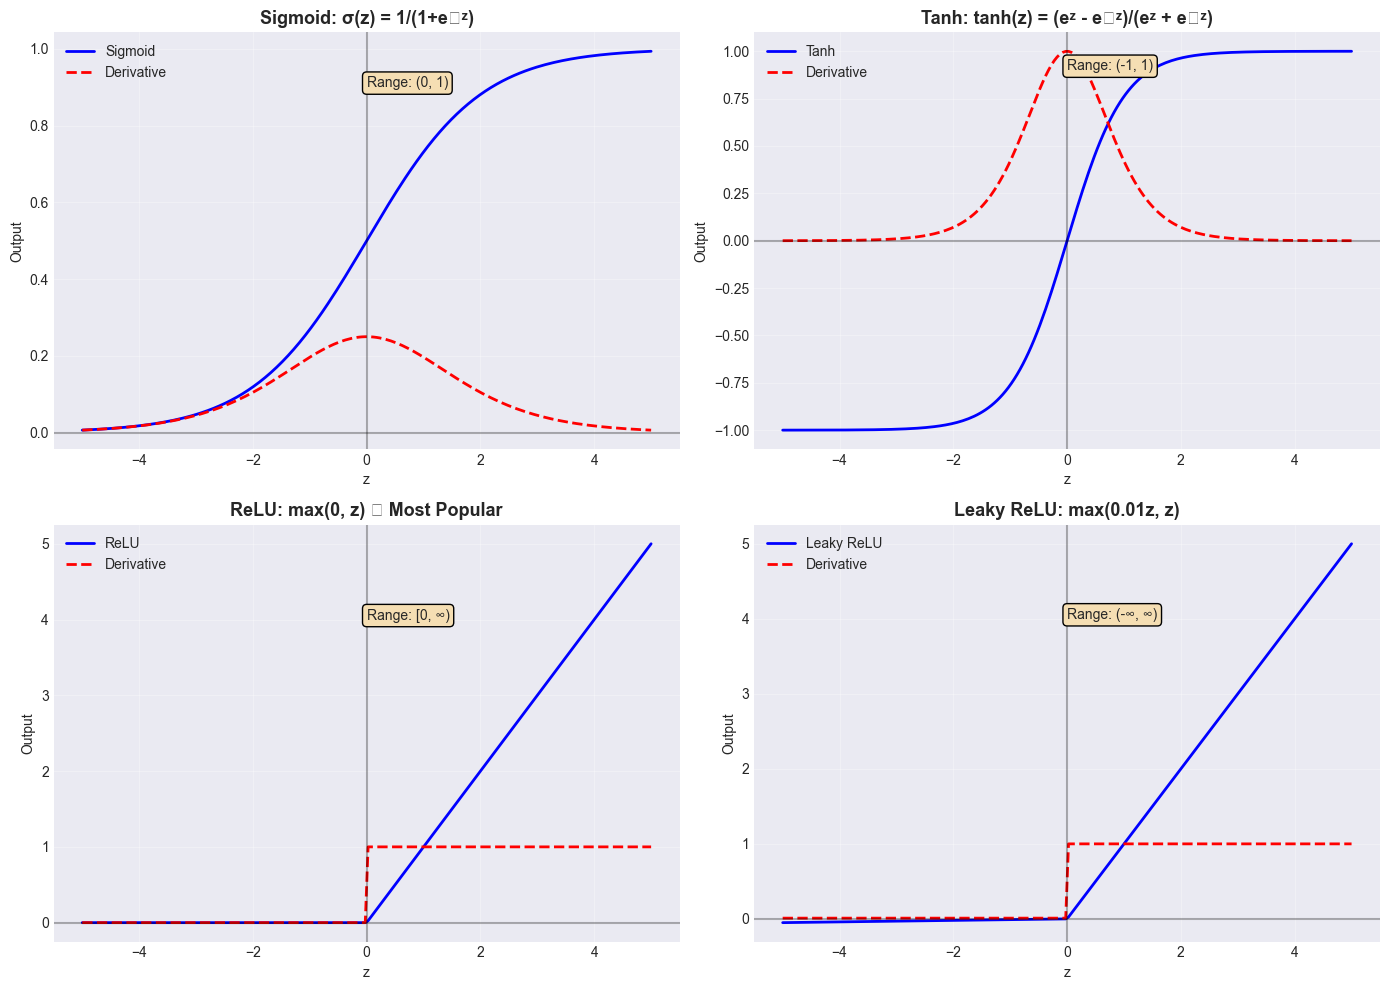


📊 Activation Function Properties:

1. Sigmoid: Good for binary classification output
   Problem: Vanishing gradient

2. Tanh: Better than sigmoid (zero-centered)
   Problem: Still vanishing gradient

3. ReLU: ⭐ DEFAULT CHOICE for hidden layers
   Pros: Fast, no vanishing gradient
   Problem: Dying ReLU (neurons can die)

4. Leaky ReLU: Fixes dying ReLU problem
   Allows small gradient when z < 0


In [11]:
# Visualize activation functions
z = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sigmoid
axes[0, 0].plot(z, sigmoid(z), 'b-', linewidth=2, label='Sigmoid')
axes[0, 0].plot(z, sigmoid_derivative(z), 'r--', linewidth=2, label='Derivative')
axes[0, 0].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[0, 0].axvline(x=0, color='k', linestyle='-', alpha=0.3)
axes[0, 0].set_title('Sigmoid: σ(z) = 1/(1+e⁻ᶻ)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('z')
axes[0, 0].set_ylabel('Output')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].text(0, 0.9, 'Range: (0, 1)', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

# Tanh
axes[0, 1].plot(z, tanh(z), 'b-', linewidth=2, label='Tanh')
axes[0, 1].plot(z, tanh_derivative(z), 'r--', linewidth=2, label='Derivative')
axes[0, 1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[0, 1].axvline(x=0, color='k', linestyle='-', alpha=0.3)
axes[0, 1].set_title('Tanh: tanh(z) = (eᶻ - e⁻ᶻ)/(eᶻ + e⁻ᶻ)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('z')
axes[0, 1].set_ylabel('Output')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].text(0, 0.9, 'Range: (-1, 1)', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

# ReLU
axes[1, 0].plot(z, relu(z), 'b-', linewidth=2, label='ReLU')
axes[1, 0].plot(z, relu_derivative(z), 'r--', linewidth=2, label='Derivative')
axes[1, 0].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[1, 0].axvline(x=0, color='k', linestyle='-', alpha=0.3)
axes[1, 0].set_title('ReLU: max(0, z) ⭐ Most Popular', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('z')
axes[1, 0].set_ylabel('Output')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].text(0, 4, 'Range: [0, ∞)', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

# Leaky ReLU
axes[1, 1].plot(z, leaky_relu(z), 'b-', linewidth=2, label='Leaky ReLU')
axes[1, 1].plot(z, leaky_relu_derivative(z), 'r--', linewidth=2, label='Derivative')
axes[1, 1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[1, 1].axvline(x=0, color='k', linestyle='-', alpha=0.3)
axes[1, 1].set_title('Leaky ReLU: max(0.01z, z)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('z')
axes[1, 1].set_ylabel('Output')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].text(0, 4, 'Range: (-∞, ∞)', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

plt.tight_layout()
plt.show()

print("\n📊 Activation Function Properties:")
print("\n1. Sigmoid: Good for binary classification output")
print("   Problem: Vanishing gradient")
print("\n2. Tanh: Better than sigmoid (zero-centered)")
print("   Problem: Still vanishing gradient")
print("\n3. ReLU: ⭐ DEFAULT CHOICE for hidden layers")
print("   Pros: Fast, no vanishing gradient")
print("   Problem: Dying ReLU (neurons can die)")
print("\n4. Leaky ReLU: Fixes dying ReLU problem")
print("   Allows small gradient when z < 0")

### 📊 Activation Functions Comparison Table

| Function | Range | Gradient | Use Case | Speed |
|----------|-------|----------|----------|-------|
| **Sigmoid** | (0, 1) | Vanishing | Binary output | Slow |
| **Tanh** | (-1, 1) | Vanishing | Hidden layers | Slow |
| **ReLU** | [0, ∞) | Good | Hidden layers ⭐ | Fast ⚡ |
| **Leaky ReLU** | (-∞, ∞) | Better | Hidden layers | Fast ⚡ |
| **Softmax** | (0, 1) Σ=1 | Good | Multi-class output | Medium |

---

## 3️⃣ Neural Network from Scratch

Endi to'liq neural network'ni noldan qilamiz!

**Architecture:**
- Input layer: 2 features
- Hidden layer: 4 neurons (ReLU)
- Output layer: 1 neuron (Sigmoid)

Bu XOR muammosini hal qiladi!

In [13]:
class NeuralNetwork:
    """Simple 2-layer Neural Network from scratch"""
    
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):
        self.lr = learning_rate
        
        # Initialize weights (Xavier initialization)
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))
        
        # Store activations for backprop
        self.a1 = None
        self.a2 = None
        self.z1 = None
        self.z2 = None
        
        # Track loss history
        self.loss_history = []
    
    def forward(self, X):
        """Forward propagation"""
        # Layer 1
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = relu(self.z1)
        
        # Layer 2 (output)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        
        return self.a2
    
    def backward(self, X, y):
        """Backpropagation"""
        m = X.shape[0]
        
        # Output layer gradients
        dz2 = self.a2 - y.reshape(-1, 1)
        dW2 = (1/m) * np.dot(self.a1.T, dz2)
        db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True)
        
        # Hidden layer gradients
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * relu_derivative(self.z1)
        dW1 = (1/m) * np.dot(X.T, dz1)
        db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True)
        
        # Update weights
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
    
    def compute_loss(self, y_true, y_pred):
        """Binary cross-entropy loss"""
        m = y_true.shape[0]
        loss = -(1/m) * np.sum(y_true * np.log(y_pred + 1e-8) + 
                              (1 - y_true) * np.log(1 - y_pred + 1e-8))
        return loss
    
    def train(self, X, y, epochs=1000, verbose=True):
        """Train the network"""
        for epoch in range(epochs):
            # Forward pass
            y_pred = self.forward(X)
            
            # Compute loss
            loss = self.compute_loss(y, y_pred)
            self.loss_history.append(loss)
            
            # Backward pass
            self.backward(X, y)
            
            # Print progress
            if verbose and (epoch + 1) % 100 == 0:
                accuracy = np.mean((y_pred > 0.5).astype(int).flatten() == y)
                print(f"Epoch {epoch+1}/{epochs} - Loss: {loss:.4f} - Accuracy: {accuracy:.2%}")
    
    def predict(self, X):
        """Make predictions"""
        y_pred = self.forward(X)
        return (y_pred > 0.5).astype(int).flatten()

print("✅ NeuralNetwork class defined!")

✅ NeuralNetwork class defined!


In [14]:
# Train on XOR problem
print("🎯 Training Neural Network on XOR problem...\n")

# Create network
nn = NeuralNetwork(input_size=2, hidden_size=4, output_size=1, learning_rate=0.5)

# Train
nn.train(X_xor, y_xor, epochs=1000, verbose=True)

# Predictions
y_pred_nn = nn.predict(X_xor)

print("\n📊 Final Results:")
print(f"Predictions: {y_pred_nn}")
print(f"True labels: {y_xor}")
print(f"Accuracy: {accuracy_score(y_xor, y_pred_nn):.2%}")
print("\n✅ SUCCESS! Neural Network solved XOR!")

🎯 Training Neural Network on XOR problem...

Epoch 100/1000 - Loss: 3.0319 - Accuracy: 75.00%
Epoch 200/1000 - Loss: 5.7541 - Accuracy: 100.00%
Epoch 300/1000 - Loss: 7.4715 - Accuracy: 100.00%
Epoch 400/1000 - Loss: 8.5761 - Accuracy: 100.00%
Epoch 500/1000 - Loss: 9.3097 - Accuracy: 100.00%
Epoch 600/1000 - Loss: 9.9022 - Accuracy: 100.00%
Epoch 700/1000 - Loss: 10.3583 - Accuracy: 100.00%
Epoch 800/1000 - Loss: 10.7573 - Accuracy: 100.00%
Epoch 900/1000 - Loss: 11.0946 - Accuracy: 100.00%
Epoch 1000/1000 - Loss: 11.3872 - Accuracy: 100.00%

📊 Final Results:
Predictions: [0 1 1 0]
True labels: [0 1 1 0]
Accuracy: 100.00%

✅ SUCCESS! Neural Network solved XOR!


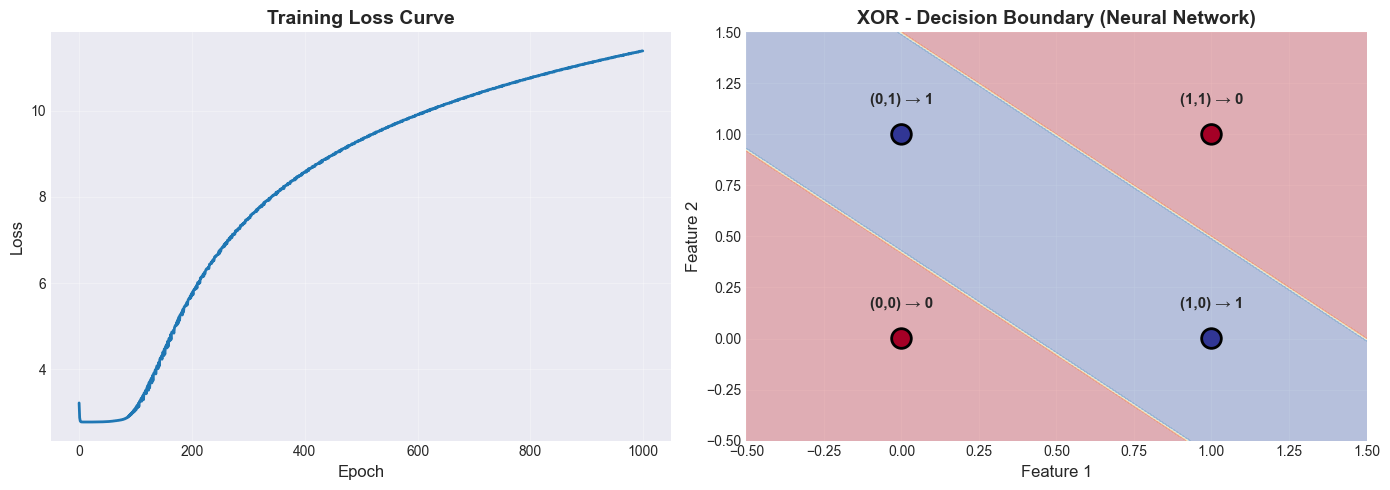


💡 Key Insight: Hidden layer learned NON-LINEAR transformation!
   This allows solving XOR which is NOT linearly separable.


In [15]:
# Visualize training and decision boundary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss curve
axes[0].plot(nn.loss_history, linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss Curve', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Decision boundary
x_min, x_max = X_xor[:, 0].min() - 0.5, X_xor[:, 0].max() + 0.5
y_min, y_max = X_xor[:, 1].min() - 0.5, X_xor[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
Z = nn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

axes[1].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
axes[1].scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, cmap='RdYlBu', 
                edgecolors='black', s=200, linewidths=2)
axes[1].set_xlabel('Feature 1', fontsize=12)
axes[1].set_ylabel('Feature 2', fontsize=12)
axes[1].set_title('XOR - Decision Boundary (Neural Network)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Add text annotations
for i, (x1, x2) in enumerate(X_xor):
    axes[1].text(x1, x2 + 0.15, f'({x1},{x2}) → {y_xor[i]}', 
                ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Key Insight: Hidden layer learned NON-LINEAR transformation!")
print("   This allows solving XOR which is NOT linearly separable.")

---

## 4️⃣ Keras - High-Level Deep Learning

**Keras** - TensorFlow ustidan qurilgan high-level API. Juda oson va tez!

### Keras Advantages:
- ✅ Beginner-friendly
- ✅ Quick prototyping
- ✅ Production-ready (TensorFlow backend)
- ✅ Sequential & Functional API
- ✅ Pre-trained models available

In [17]:
# Keras XOR solution - SO SIMPLE!
from tensorflow import keras
from tensorflow.keras import layers

print("🔧 Building Keras model for XOR...")

# Create model
model_xor = keras.Sequential([
    layers.Dense(4, activation='relu', input_shape=(2,), name='hidden'),
    layers.Dense(1, activation='sigmoid', name='output')
])

# Compile model
model_xor.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print model summary
print("\n📊 Model Architecture:")
model_xor.summary()

# Train model
print("\n🎯 Training...")
history = model_xor.fit(
    X_xor, y_xor,
    epochs=500,
    verbose=1,
    batch_size=4
)

# Evaluate
loss, accuracy = model_xor.evaluate(X_xor, y_xor, verbose=0)
predictions = (model_xor.predict(X_xor, verbose=0) > 0.5).astype(int).flatten()

print(f"\n📊 Results:")
print(f"Predictions: {predictions}")
print(f"True labels: {y_xor}")
print(f"Accuracy: {accuracy:.2%}")
print("\n✅ Keras solved XOR with just 5 lines of code!")

🔧 Building Keras model for XOR...

📊 Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden (Dense)                  │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)


🎯 Training...
Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7500 - loss: 0.8439
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7500 - loss: 0.8422
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7500 - loss: 0.8404
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7500 - loss: 0.8387
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7500 - loss: 0.8369
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7500 - loss: 0.8352
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7500 - loss: 0.8335
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7500 - loss: 0.8318
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7500 - loss: 0.8302
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7500 - loss: 0.8285
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7500 - loss: 0.8269
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy

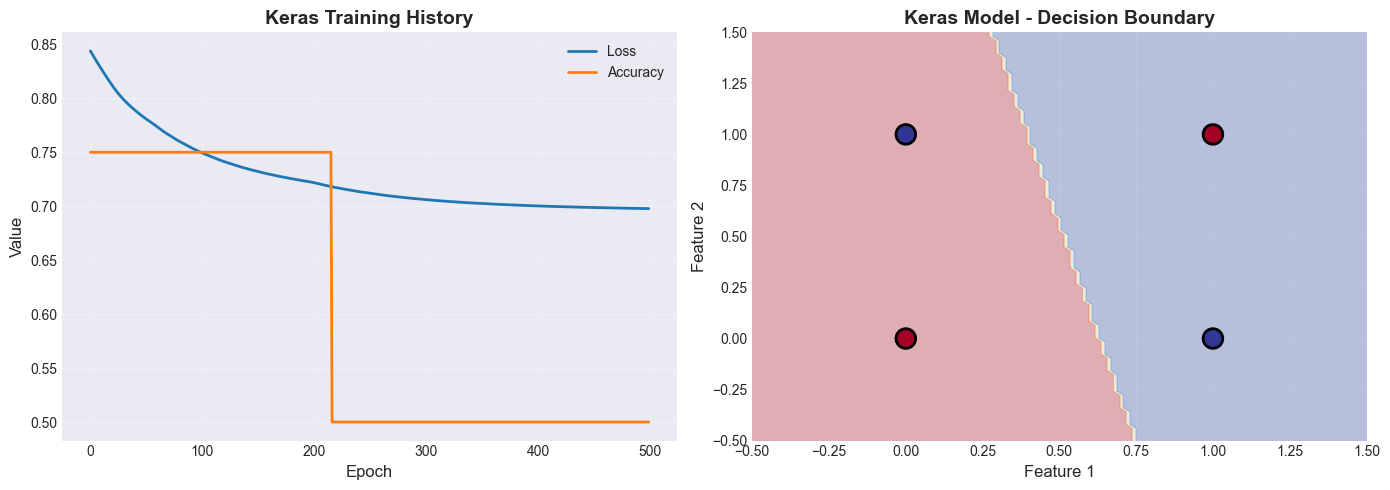

✅ Keras model visualization complete!


In [18]:
# Visualize Keras training
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss and Accuracy
axes[0].plot(history.history['loss'], label='Loss', linewidth=2)
axes[0].plot(history.history['accuracy'], label='Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Value', fontsize=12)
axes[0].set_title('Keras Training History', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Decision boundary
x_min, x_max = X_xor[:, 0].min() - 0.5, X_xor[:, 0].max() + 0.5
y_min, y_max = X_xor[:, 1].min() - 0.5, X_xor[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
Z = (model_xor.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0) > 0.5).astype(int)
Z = Z.reshape(xx.shape)

axes[1].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
axes[1].scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, cmap='RdYlBu', 
                edgecolors='black', s=200, linewidths=2)
axes[1].set_xlabel('Feature 1', fontsize=12)
axes[1].set_ylabel('Feature 2', fontsize=12)
axes[1].set_title('Keras Model - Decision Boundary', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Keras model visualization complete!")

### 🎯 Real Dataset - MNIST Digits

MNIST - handwritten digits (0-9) classification. **Deep Learning'ning "Hello World"i**!

Dataset:
- 60,000 training images
- 10,000 test images
- Image size: 28×28 pixels
- 10 classes (0-9)

📥 Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

📊 Dataset Info:
Training set: (60000, 28, 28)
Test set: (10000, 28, 28)
Image shape: (28, 28)
Labels: [0 1 2 3 4 5 6 7 8 9]


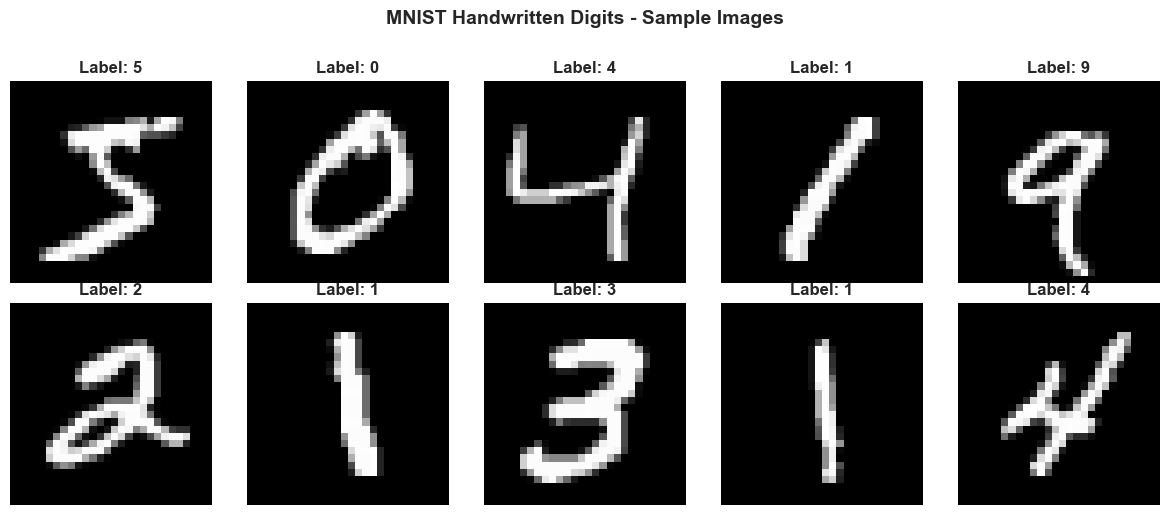


✅ Dataset loaded successfully!


In [19]:
# Load MNIST dataset
print("📥 Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f"\n📊 Dataset Info:")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Image shape: {X_train[0].shape}")
print(f"Labels: {np.unique(y_train)}")

# Visualize some samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}', fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('MNIST Handwritten Digits - Sample Images', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✅ Dataset loaded successfully!")

In [20]:
# Preprocess data
print("🔧 Preprocessing data...")

# Flatten images: 28x28 -> 784
X_train_flat = X_train.reshape(-1, 784)
X_test_flat = X_test.reshape(-1, 784)

# Normalize: 0-255 -> 0-1
X_train_flat = X_train_flat.astype('float32') / 255.0
X_test_flat = X_test_flat.astype('float32') / 255.0

print(f"\n📊 After preprocessing:")
print(f"X_train shape: {X_train_flat.shape}")
print(f"X_test shape: {X_test_flat.shape}")
print(f"Data range: [{X_train_flat.min():.1f}, {X_train_flat.max():.1f}]")
print("\n✅ Preprocessing complete!")

🔧 Preprocessing data...

📊 After preprocessing:
X_train shape: (60000, 784)
X_test shape: (10000, 784)
Data range: [0.0, 1.0]

✅ Preprocessing complete!


In [21]:
# Build MNIST classifier
print("🏗️ Building Neural Network for MNIST...")

model_mnist = keras.Sequential([
    # Input layer (784 pixels)
    layers.Dense(128, activation='relu', input_shape=(784,), name='hidden1'),
    
    # Second hidden layer
    layers.Dense(64, activation='relu', name='hidden2'),
    
    # Output layer (10 classes)
    layers.Dense(10, activation='softmax', name='output')
])

# Compile
model_mnist.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print summary
print("\n📊 Model Architecture:")
model_mnist.summary()

print("\n💡 Key Points:")
print("- Hidden layers use ReLU activation")
print("- Output layer uses Softmax (10 classes)")
print("- Loss: Sparse Categorical Crossentropy")
print("- Optimizer: Adam")

🏗️ Building Neural Network for MNIST...

📊 Model Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


💡 Key Points:
- Hidden layers use ReLU activation
- Output layer uses Softmax (10 classes)
- Loss: Sparse Categorical Crossentropy
- Optimizer: Adam


In [22]:
# Train model
print("🎯 Training MNIST classifier...")
print("(This may take 1-2 minutes)\n")

history_mnist = model_mnist.fit(
    X_train_flat, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    verbose=1
)

print("\n✅ Training complete!")

🎯 Training MNIST classifier...
(This may take 1-2 minutes)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7899 - loss: 0.6994 - val_accuracy: 0.9166 - val_loss: 0.2974
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9094 - loss: 0.3306 - val_accuracy: 0.9019 - val_loss: 0.3557
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8909 - loss: 0.4046 - val_accuracy: 0.8722 - val_loss: 0.5150
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8740 - loss: 0.5460 - val_accuracy: 0.8264 - val_loss: 0.9539
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8519 - loss: 0.8436 - val_accuracy: 0.7913 - val_loss: 1.5777
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8357 - loss: 1.1755 - val_accuracy: 0.8238 - val_loss: 1.3925
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8419 - loss: 1.3916 - val_accuracy: 0.8284 - val_loss: 1.5123
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━

In [ ]:
# Evaluate on test set
print("📊 Evaluating on test set...")

test_loss, test_accuracy = model_mnist.evaluate(X_test_flat, y_test, verbose=0)

print(f"\n🎯 Test Results:")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_accuracy:.2%}")

# Make predictions
y_pred = model_mnist.predict(X_test_flat, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1) # 0 .. 9 sonlar orasida qaysi classga tegishli ekanligini aniqlab beradi 

print(f"\n📊 Classification Report:")
print(classification_report(y_test, y_pred_classes, digits=3))

📊 Evaluating on test set...

🎯 Test Results:
Loss: 2.7775
Accuracy: 81.52%

📊 Classification Report:
              precision    recall  f1-score   support

           0      0.892     0.959     0.924       980
           1      0.935     0.977     0.956      1135
           2      0.873     0.806     0.838      1032
           3      0.857     0.653     0.742      1010
           4      0.934     0.668     0.779       982
           5      0.760     0.555     0.642       892
           6      0.888     0.920     0.904       958
           7      0.910     0.906     0.908      1028
           8      0.541     0.838     0.658       974
           9      0.717     0.825     0.767      1009

    accuracy                          0.815     10000
   macro avg      0.831     0.811     0.812     10000
weighted avg      0.833     0.815     0.815     10000



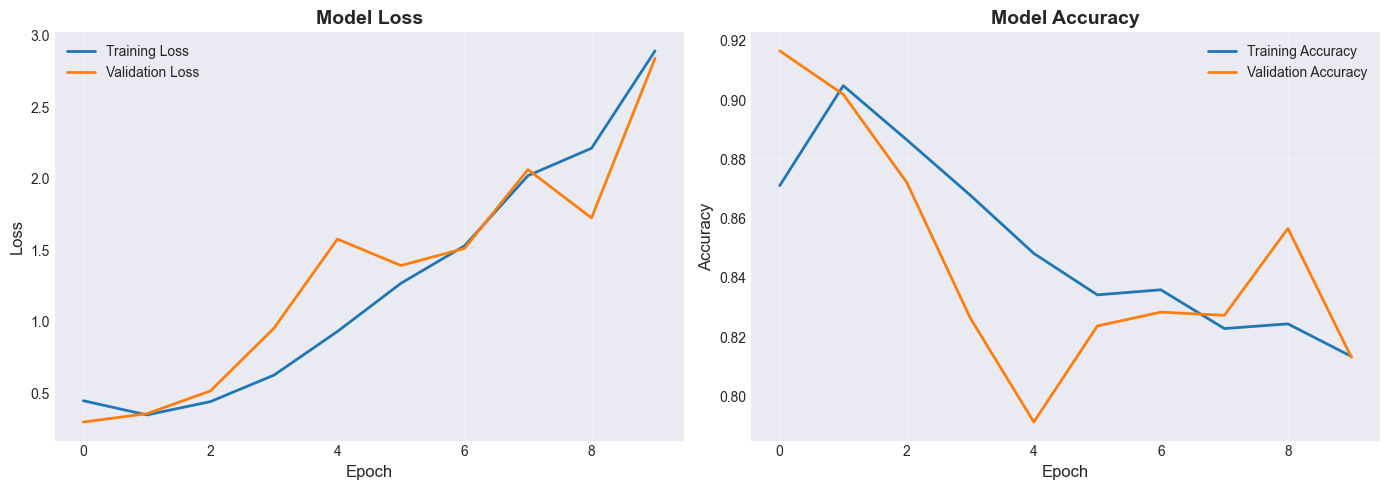

✅ Training history visualization complete!


In [24]:
# Visualize training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss
axes[0].plot(history_mnist.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history_mnist.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy
axes[1].plot(history_mnist.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history_mnist.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Training history visualization complete!")

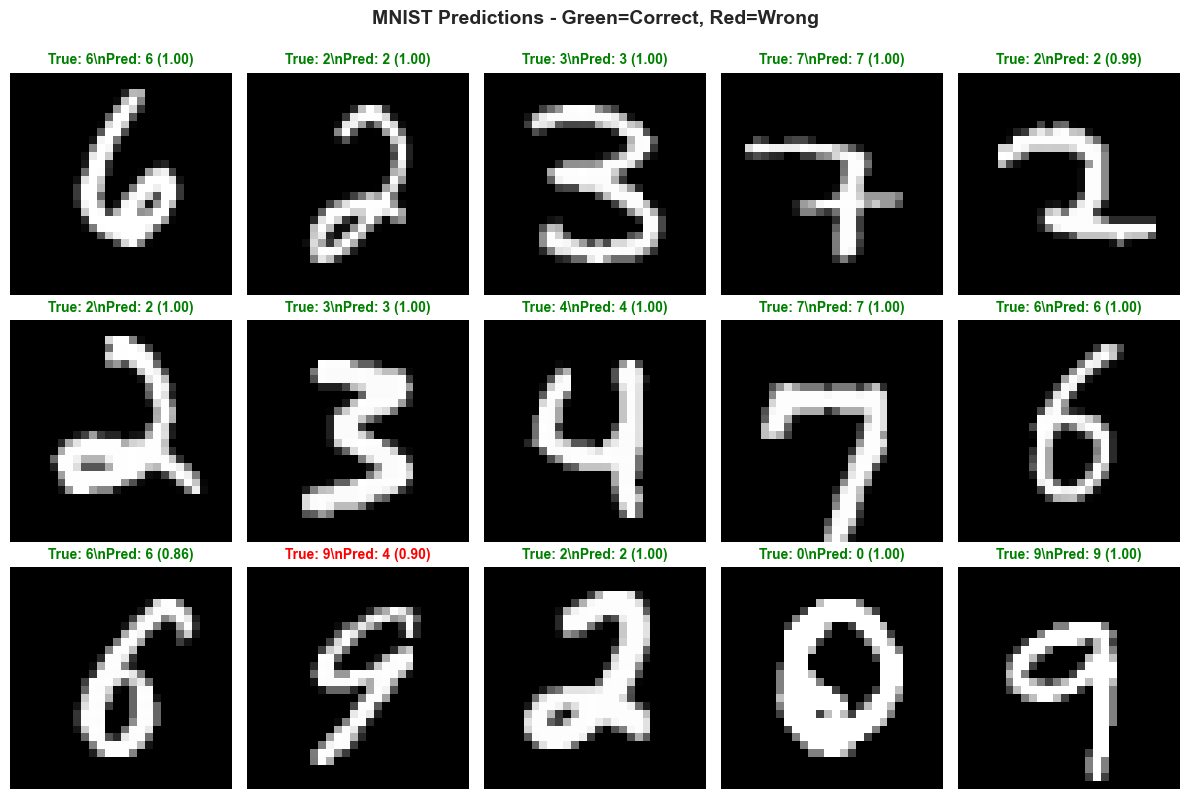


✅ Correct: 8152/10000 (81.52%)


In [25]:
# Visualize predictions
fig, axes = plt.subplots(3, 5, figsize=(12, 8))

# Get random test samples
np.random.seed(42)
random_indices = np.random.choice(len(X_test), 15, replace=False)

for i, ax in enumerate(axes.flat):
    idx = random_indices[i]
    
    # Show image
    ax.imshow(X_test[idx], cmap='gray')
    
    # Get prediction
    true_label = y_test[idx]
    pred_label = y_pred_classes[idx]
    pred_prob = y_pred[idx][pred_label]
    
    # Color: green if correct, red if wrong
    color = 'green' if true_label == pred_label else 'red'
    
    ax.set_title(f'True: {true_label}\\nPred: {pred_label} ({pred_prob:.2f})', 
                 fontsize=10, fontweight='bold', color=color)
    ax.axis('off')

plt.suptitle('MNIST Predictions - Green=Correct, Red=Wrong', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Count correct/incorrect
correct = np.sum(y_test == y_pred_classes)
total = len(y_test)
print(f"\n✅ Correct: {correct}/{total} ({100*correct/total:.2f}%)")

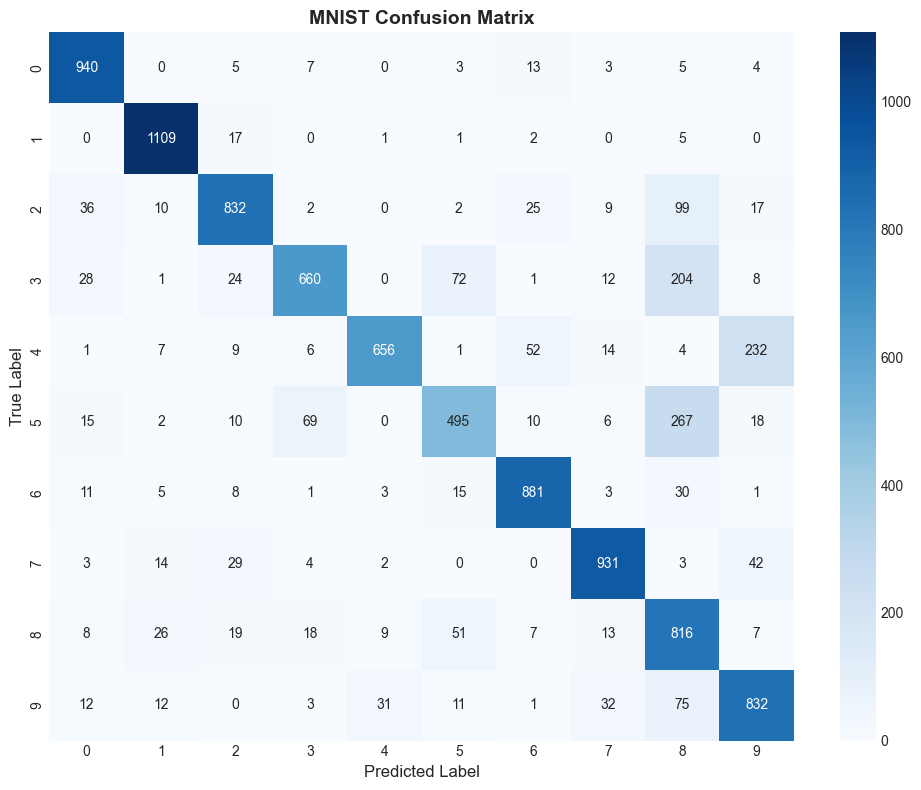

✅ Confusion matrix visualization complete!


In [26]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('MNIST Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Confusion matrix visualization complete!")

---

## 5️⃣ PyTorch Basics

**PyTorch** - Facebook (Meta) tomonidan yaratilgan research framework.

### PyTorch vs Keras:

| Feature | Keras | PyTorch |
|---------|-------|---------|
| **Level** | High-level | Low-level |
| **Ease** | ✅ Very Easy | ⚠️ More Complex |
| **Flexibility** | ⚠️ Limited | ✅ Very Flexible |
| **Research** | Good | ✅ Excellent |
| **Production** | ✅ TensorFlow backend | ⚠️ TorchServe |
| **Debugging** | ⚠️ Harder | ✅ Pythonic |

### When to use what?

**Use Keras if:**
- Quick prototyping
- Standard architectures
- Production deployment
- Beginner-friendly

**Use PyTorch if:**
- Custom architectures
- Research projects
- Maximum flexibility
- You like Python debugging

In [ ]:
# PyTorch Example (Optional - requires PyTorch installation)
# Uncomment if you have PyTorch installed

print("📦 PyTorch Example Code:")
import torch
import torch.nn as nn
import torch.optim as optim

# Define model
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  # No softmax (included in CrossEntropyLoss)
        return x

# Create model
model = SimpleNN()

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
for epoch in range(10):
    for batch_X, batch_y in train_loader:
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

print("\\n💡 Key Differences:")
print("1. Define custom class inheriting nn.Module")
print("2. Implement forward() method")
print("3. Manual training loop")
print("4. More control, more code")
print("\\n⚠️ PyTorch installation required to run this code")

---

## 🎯 Summary va Key Takeaways

### What we learned:

1. **Perceptron** ✅
   - Single neuron
   - Linear separation only
   - Cannot solve XOR

2. **Multi-layer Networks** ✅
   - Multiple hidden layers
   - Non-linear transformations
   - Can solve XOR!

3. **Activation Functions** ✅
   - ReLU - Default for hidden layers
   - Sigmoid - Binary output
   - Softmax - Multi-class output

4. **Forward Propagation** ✅
   - Input → Hidden → Output
   - Matrix multiplication + activation

5. **Backpropagation** ✅
   - Calculate gradients (chain rule)
   - Update weights
   - Minimize loss

6. **Keras** ✅
   - High-level, easy
   - Quick prototyping
   - Production-ready

7. **PyTorch** ✅
   - Low-level, flexible
   - Research-friendly
   - More control

### 🏆 Best Practices Checklist:

- ✅ Use **ReLU** for hidden layers
- ✅ Use **Adam** optimizer (default)
- ✅ **Normalize** input data (0-1 or StandardScaler)
- ✅ Start with **simple architecture**
- ✅ Add layers gradually
- ✅ Monitor **val_loss** (overfitting)
- ✅ Use **batch normalization**
- ✅ Use **dropout** to prevent overfitting

### 📚 Recommended Architecture for Beginners:

```python
model = keras.Sequential([
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),  # Prevent overfitting
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
```

### 🚀 Next Steps:

1. Complete `practical.ipynb` exercises
2. Do `homework.md` assignments
3. Read `deep_learning_guide.md` reference
4. Experiment with different architectures
5. Try on your own datasets!

---

**Congratulations!** 🎉 You now understand neural network fundamentals!

**Ready to practice?** Open `practical.ipynb`! 💪